# Mulitvariate VS Univariate

Univariate
when we fill our missing value with our same column value	

Multivariate
We can fill the missing values with any column of our dataset

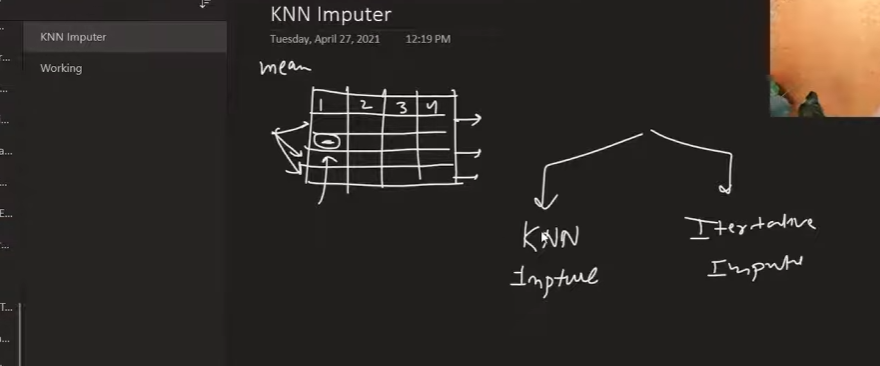


KNN Imputation Notes:
We fill the missing value with the most similar row value.

How it works:
For the value we need to fill, we calculate the Euclidean distance from that row to every other row. The row that is closest is used to replace the missing feature value.

Understanding K(Number of Neighbors)

K = Number of neighbors.

If K = 1: We take the closest neighbor's feature value and replace the missing value.

If K >=2: We take the average (sum divided by the total number of neighbors) of their values.

example: 

 Finding missing values:
If we need to find out a NaN value from row 1 to row 4, we look at rows with no missing values, find the similarities, and use differences like (x2 - x1).

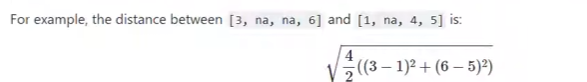

where 4/2 is weight :

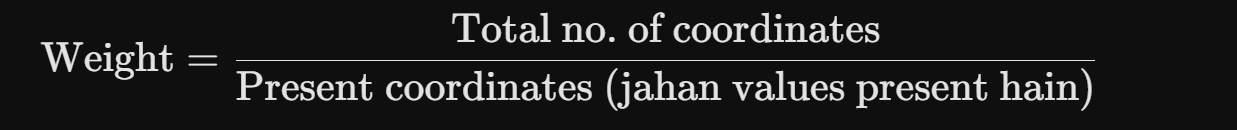


Advantage:
* More accurate

Disadvantages:
* More number of calculations
* High computational demand during predictions and training time

# Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('titanic.csv',usecols = ['Age','Pclass', 'Fare','Survived'])

In [3]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Pclass       0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
x= df.drop(columns = ['Survived'])
y = df['Survived']


In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 2)

In [7]:
x_train.head()

,Pclass,Age,Fare
30,1,40.0,27.7208
10,3,4.0,16.7000
873,3,47.0,9.0000
182,3,9.0,31.3875
876,3,20.0,9.8458


In [8]:
knn = KNNImputer(n_neighbors = 1) # default value of n_neighbors is 5
knn = KNNImputer(n_neighbors = 1,weights = 'distance') # here we do distance reciprocal * its value . 

x_train_trf = knn.fit_transform(x_train)

x_test_trf = knn.transform(x_test)

In [9]:
pd.DataFrame(x_train_trf, columns=x_train.columns)

,Pclass,Age,Fare
0,1.0,40.0,27.7208
1,3.0,4.0,16.7000
2,3.0,47.0,9.0000
3,3.0,9.0,31.3875
4,3.0,20.0,9.8458
...,...,...,...
707,3.0,30.0,8.6625
708,3.0,31.0,8.7125
709,1.0,71.0,49.5042
710,1.0,18.0,221.7792


In [10]:
lr = LogisticRegression()
lr.fit(x_train_trf,y_train)
y_pred = lr.predict(x_test_trf)
accuracy_score(y_test,y_pred)

0.6871508379888268

In [13]:
# Comparison with simple imputer -->

si = SimpleImputer()
x_train_trf2 = si.fit_transform(x_train)
x_test_trf2 = si.transform(x_test)

In [15]:
lr = LogisticRegression()
lr.fit(x_train_trf2,y_train)
y_predict2 = lr.predict(x_test_trf2)
accuracy_score(y_test, y_predict2)

0.6927374301675978